In [1]:
from coffea.nanoevents import NanoAODSchema
from coffea.dataset_tools import apply_to_fileset, max_chunks, max_files, preprocess

import dask

from analysis_tools.processors.processor_26_2_25 import MyProcessor
from dask.distributed import Client

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [2]:
import gzip
import json
import os

# Define the base directory where the preprocessed files are stored
base_dir = "/home/cms-jovyan/dwg_analysis/tools/preprocessing/preprocessed"
signal_sample = "2023_SlepSnu_MN1_270_100000_preprocessed_available.json.gz"
#signal_sample = "2023_ttbar_100000_preprocessed_available.json.gz"
background_sample = "2023_ttbar_100000_preprocessed_available.json.gz"
signal_file_path = os.path.join(base_dir, signal_sample)
background_file_path = os.path.join(base_dir, background_sample)
#print(preprocessed)

with gzip.open(signal_file_path, "rt") as file:
    signal_preprocessed_available = json.load(file)
with gzip.open(background_file_path, "rt") as file:
    background_preprocessed_available = json.load(file)

In [3]:
client = Client("tls://localhost:8786")
client

Connection method: Direct,
Dashboard: /user/derek.william.grove@cern.ch/proxy/8787/status,
Comm: tls://192.168.235.66:8786,Workers: 0
Dashboard: /user/derek.william.grove@cern.ch/proxy/8787/status,Total threads: 0
Started: 7 hours ago,Total memory: 0 B


In [4]:
signal_test_preprocessed_files = max_files(signal_preprocessed_available, 5)
signal_test_preprocessed = max_chunks(signal_test_preprocessed_files, 1)

### SWITCH HERE ###

signal_reduced_computation = False

###################

# signal

if signal_reduced_computation:
    small_tg, small_rep = apply_to_fileset(
        data_manipulation=MyProcessor(),
        fileset=signal_test_preprocessed,
        schemaclass=NanoAODSchema,
        uproot_options={"allow_read_errors_with_report": (OSError, KeyError)},
    )
    signal_computed, rep = dask.compute(small_tg, small_rep)
    
else:
    full_tg, full_rep = apply_to_fileset(
        data_manipulation=MyProcessor(),
        fileset=signal_preprocessed_available,
        schemaclass=NanoAODSchema,
        uproot_options={"allow_read_errors_with_report": (OSError, KeyError)},
    )
    signal_computed, rep = dask.compute(full_tg, full_rep)


In [5]:
signal_computed

{'/SlepSnuCascade_MN1-270_MN2-280_MC1-275_TuneCP5_13p6TeV_madgraphMLM-pythia8/Run3Summer23BPixNanoAODv12-130X_mcRun3_2023_realistic_postBPix_v6-v3/NANOAODSIM': {'counts': {'total entries': 459524,
   'total electrons': 345260,
   'count_filtered_ele': 72689,
   'count_blp_ele': 47787,
   'count_gold_ele': 34635,
   'count_silver_ele': 5444,
   'count_bronze_ele': 7708},
  'pt_binned': {},
  'calculations': {},
  'plots': {'gold_hoe_pt_dist': Hist(
     Regular(60, 0, 1.2, name='hoe'),
     Regular(60, 5, 35, name='pt'),
     storage=Double()) # Sum: 19759.0 (34635.0 with flow),
   'blp_hoe_pt_dist': Hist(
     Regular(60, 0, 1.2, name='hoe'),
     Regular(60, 5, 35, name='pt'),
     storage=Double()) # Sum: 28126.0 (47787.0 with flow),
   'blp_mini_iso_pt_dist': Hist(
     Regular(50, 0, 2, name='mini_iso'),
     Regular(90, 5, 50, name='pt'),
     storage=Double()) # Sum: 36870.0 (47787.0 with flow),
   'gold_mini_iso_pt_dist': Hist(
     Regular(50, 0, 2, name='mini_iso'),
     Regul

In [6]:
sig_results = signal_computed['/SlepSnuCascade_MN1-270_MN2-280_MC1-275_TuneCP5_13p6TeV_madgraphMLM-pythia8/Run3Summer23BPixNanoAODv12-130X_mcRun3_2023_realistic_postBPix_v6-v3/NANOAODSIM']
#sig_results = signal_computed['/TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8/Run3Summer23NanoAODv12-130X_mcRun3_2023_realistic_v14-v2/NANOAODSIM']

Shooting for ~ 459524 events for ttbar

In [7]:
sig_results

{'counts': {'total entries': 459524,
  'total electrons': 345260,
  'count_filtered_ele': 72689,
  'count_blp_ele': 47787,
  'count_gold_ele': 34635,
  'count_silver_ele': 5444,
  'count_bronze_ele': 7708},
 'pt_binned': {},
 'calculations': {},
 'plots': {'gold_hoe_pt_dist': Hist(
    Regular(60, 0, 1.2, name='hoe'),
    Regular(60, 5, 35, name='pt'),
    storage=Double()) # Sum: 19759.0 (34635.0 with flow),
  'blp_hoe_pt_dist': Hist(
    Regular(60, 0, 1.2, name='hoe'),
    Regular(60, 5, 35, name='pt'),
    storage=Double()) # Sum: 28126.0 (47787.0 with flow),
  'blp_mini_iso_pt_dist': Hist(
    Regular(50, 0, 2, name='mini_iso'),
    Regular(90, 5, 50, name='pt'),
    storage=Double()) # Sum: 36870.0 (47787.0 with flow),
  'gold_mini_iso_pt_dist': Hist(
    Regular(50, 0, 2, name='mini_iso'),
    Regular(90, 5, 50, name='pt'),
    storage=Double()) # Sum: 26473.0 (34635.0 with flow),
  'gold_pt_dist': Hist(Regular(45, 5, 50, name='gold pt'), storage=Double()) # Sum: 26473.0 (34635.

75578

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f7a0d79eea0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f7a0dadd070>, text=[])

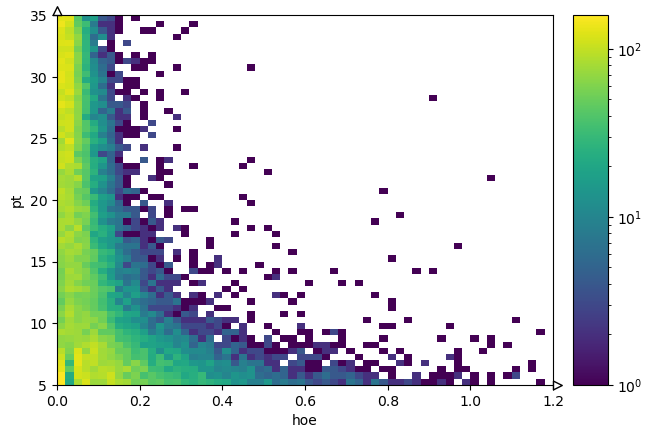

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
plt.figure()
#hist_object.plot2d(norm=colors.LogNorm())

sig_results["plots"]["blp_hoe_pt_dist"].plot2d(norm=colors.LogNorm())

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f7a0d642bd0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f7a0d740f80>, text=[])

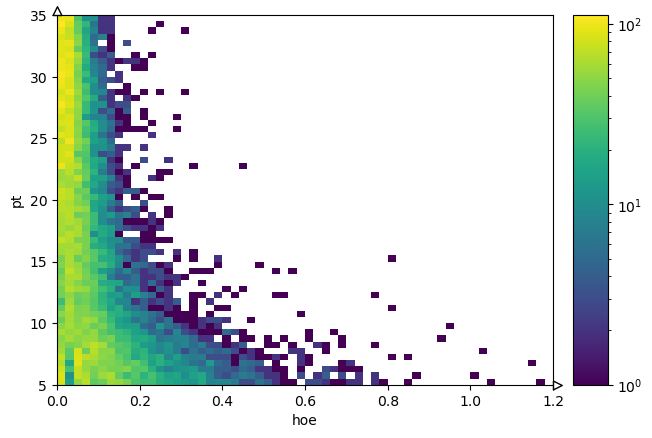

In [9]:
sig_results["plots"]["gold_hoe_pt_dist"].plot2d(norm=colors.LogNorm())

In [10]:
sig_results["plots"]["gold_hoe_pt_dist"]/sig_results["plots"]["blp_hoe_pt_dist"]

Hist(
  Regular(60, 0, 1.2, name='hoe'),
  Regular(60, 5, 35, name='pt'),
  storage=Double()) # Sum: nan (nan with flow)

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f7a0d83fd70>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f7a0d523650>, text=[])

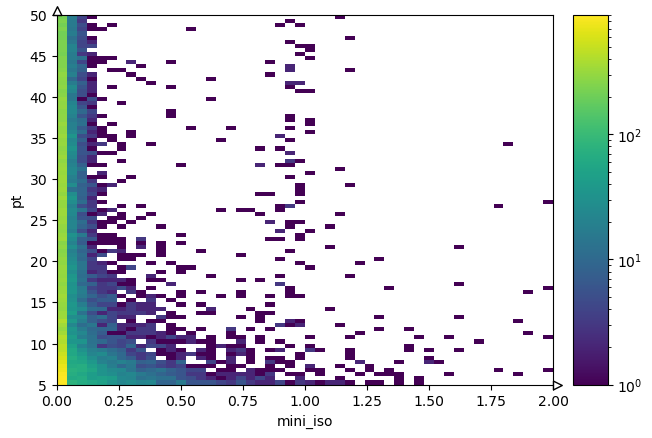

In [11]:
sig_results["plots"]["blp_mini_iso_pt_dist"].plot2d(norm=colors.LogNorm())

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f7a0d2bbe00>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f7a0d220050>, text=[])

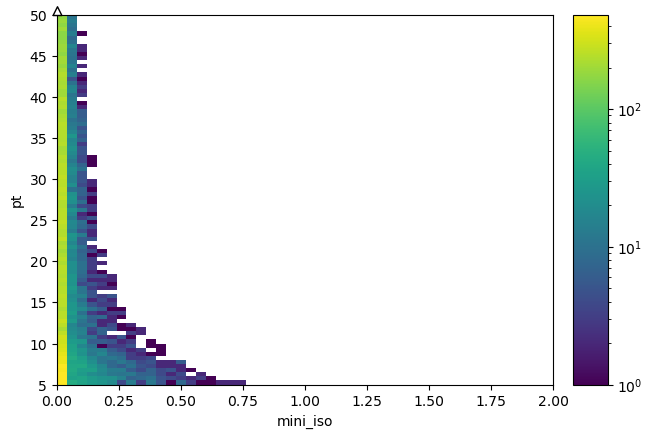

In [12]:
sig_results["plots"]["gold_mini_iso_pt_dist"].plot2d(norm=colors.LogNorm())

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7a0d1c0b60>, errorbar=None, legend_artist=None)]

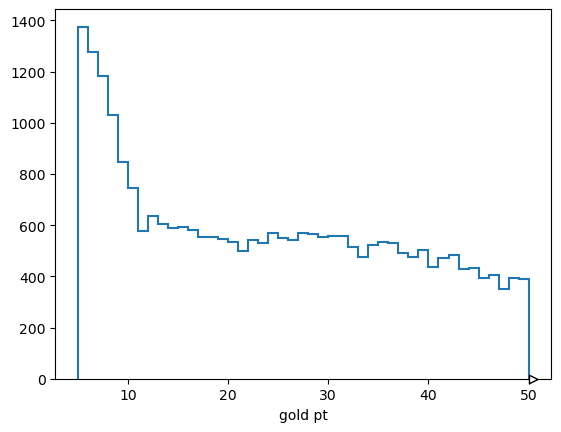

In [13]:
hist_1 = sig_results["plots"]["gold_pt_dist"]
hist_1.plot1d()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7a0d1639b0>, errorbar=None, legend_artist=None)]

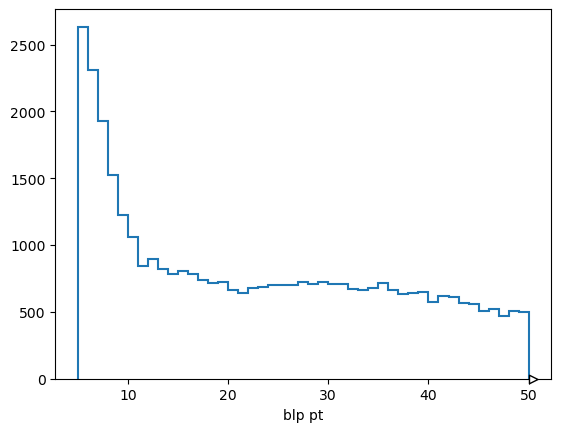

In [14]:
hist_2 = sig_results["plots"]["blp_pt_dist"]
hist_2.plot1d()

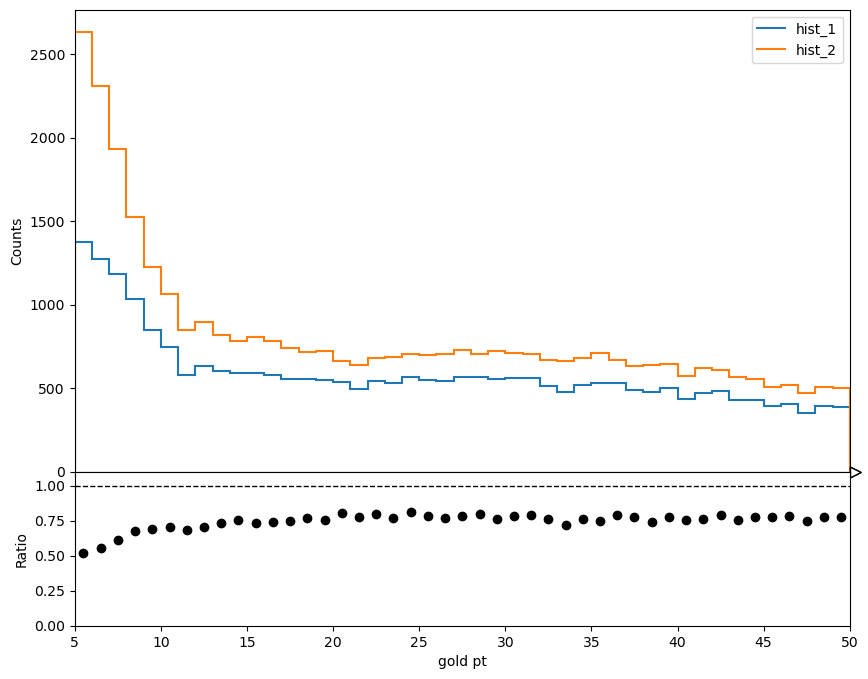

In [15]:
fig = plt.figure(figsize=(10, 8))

main_ax_artists, sublot_ax_arists = hist_1.plot_ratio(
    hist_2,
    rp_ylabel=r"Ratio",
    rp_num_label="hist_1",
    rp_denom_label="hist_2",
    rp_uncert_draw_type="line",
    rp_uncertainty_type="efficiency"
)